<a href="https://colab.research.google.com/github/lee-woonju/study-hongong-mldl/blob/main/05_1_%EA%B2%B0%EC%A0%95%ED%8A%B8%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 트리 알고리즘
## KEYWORD : 결정트리, 불순도, 정보 이득, 가져가기, 특성 중요도


In [2]:
# 로지스틱 회귀로 와인 분류하기
import pandas as pd
wine = pd.read_csv('https://bit.ly/wine_csv_data')
wine.head()

# .info() :데이터프레임의 각 열의 데이터 타입과 누락된 데이터가 있는지 확인하는데 유용
wine.info()

# .describe() : 열에 대한 간략한 통계 출력
wine.describe()

# 알콜도수, 당도, pH 스케일 다름 => 표준화 필요 !

#=========================================================================
# 우선, 특성과 타깃 추출
data = wine[['alcohol', 'sugar', 'pH']]
target = wine['class']

# 훈련 세트와 테스트 세트로 나누기
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(data, target, test_size=0.2, random_state=42)

print(train_input.shape, test_input.shape)

# 표준화
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)
# =====================================================================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB
(5197, 3) (1300, 3)


In [3]:
# 로지스틱 회귀모델 훈련
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.7808350971714451
0.7776923076923077


## 로지스틱 회귀 모델
- 실제로는 '분류' 모델
- 주로 이진분류 문제에 사용되지만 다중분류로 확장될 수 있음

### 특징
1. **시그모이드 함수* : 선형 모델의 출력값을 0~1사이 값으로 압축하는 함수. 0~1 사이의 값은 **확률**
2. 확률 예측 : 0.5보다 크면 1(양성 클래스), 작으면 0(음성 클래스)으로 분류
3. 클래스 확률 계산 : .predict_proba() 메서드로 각 클래스에 대한 확률 얻을 수 있음

## 결정트리
> 이유를 설명하기 쉽다

사이킷런의 **DecisionTreeClassifier** 클래스 사용




0.996921300750433
0.8592307692307692


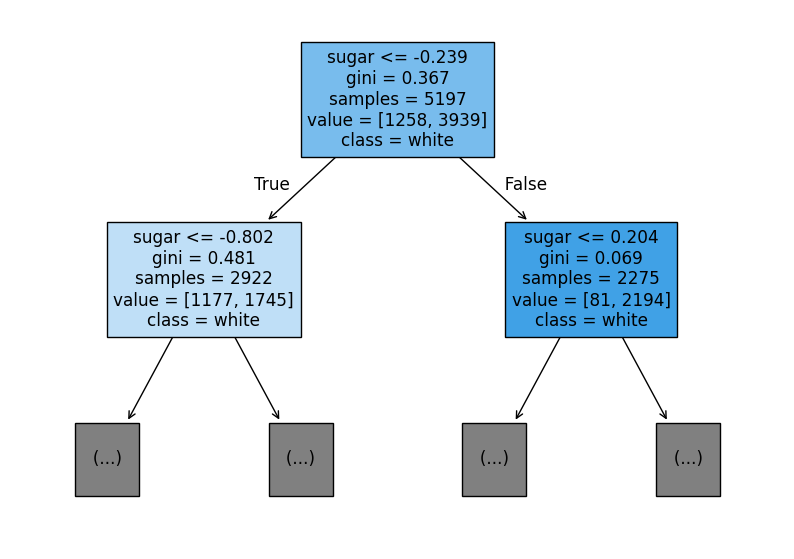

In [9]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

# 그림으로 표현하기 : plot_tree()
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10,7)) # Increased figure size for better readability
plot_tree(dt, max_depth=1, filled=True, feature_names=['alcohol', 'sugar', 'pH'], class_names=['red', 'white'])
plt.show()


### 결정 트리에서 예측
- 한 노드에서 질문했을 때, 더 많은 샘플이 이동한 가지가 이 노드의 **예측클래스**이자 **양성클래스**가 됨
- 로지스틱회귀처럼 음성/양성 클래스를 고정해놓고 확률 임계치(0.5)로 나누는 방식과는 다름

### 헷갈렸던 부분
> 루트노드에서 value = [1258, 3939]인 것을 YES=1258개, NO=3939개라고 착각함
```
# 의식의 흐름..
- yes가 1258, no가 3939, 1258이 음성 클래스라구?
- 그럼 yes쪽으로 이동하는 게 음성클래스? => 아님
- 트리노드는 항상 음성클래스가 yes로 가도록 질문하는 건가? => 아님

- 다음 노드에서 전체 sample의 개수가 1258이 아닌 걸 눈치챔
- 갑자기 이해 완료
```
- plot_tree의 class_names=['red', 'white']에서 이미 음성클래스와 양성클래스를 지정함( red/음성/0,white/양성/1 )
- value는 현재 노드에서 샘플의 분포를 나타냄

> **리프노드**에서 가장 많은 클래스가 예측 클래스가 된다!


## 불순도
DecisionTreeClassfier클래스의 criterion 매개변수, 기본값 = gini
> criterion : 노드에서 데이터를 분할할 기준을 정하는 것

### 지니 불순도
$지니 불순도 = 1- (음성 클래스 비율 ^2 + 양성클래스비율^2) $

- 어느 노드의 두 클래스의 비율이 정확이 1:1이라면 ? 지니 불순도 = 0.5 = 최악!  $⇒$ 가장 불순한 상태
- 어느 노드에 하나의 클래스만 있다면 ? 지니 불순도 = 0 = 최고! $⇒$ 순수노드

> 지니불순도 = 0.5가 최악인 이유<br>
> $⇒$ 예측 클래스를 정할 수 없으니까

## 정보 이득
결정 트리 모델은 부모노드와 자식노드의 불순도 차이가 가능한 크도록 트리를 성장시킴
> 부모의 불순도 - 왼쪽자식노드의 가중불순도 - 오른쪽자식노드의 가중불순도
- 자식노드들의 가중불순도는 항상 0 이상이므로, 정보 이득이 최대가 되는 경우는 자식 노드의 가중불순도가 0일 때 = 자식 노드들이 완전히 순수해질 때

★ 알겠다
- 트리 분할 방향을 정하는 건 = 정보 이득
- 정보 이득 계산을 위해 불순도 사용

---
## 여기까지 정리
- 결정 트리 모델은 루트 노드부터 리프 노드까지 질문을 거듭하여 가장 많은 예측 클래스를 찾는 것
- criterion 매개변수의 기본값 gini. 지니 불순도 : 노드 분할 기준
>분할 전보다 분할 후에 지니 불순도를 가장 많이 낮추도록(가능한 **순수하게** 되도록) 하는 분할 기준을 선택
- 정보 이득 : 부모와 자식 노드 사이의 불순도 차이
> 자식 노드들이 완전히 순수해질 때 최대가 됨. 최대 = 부모의 불순도

---

## 가지치기
무작정 끝까지 자라나는 트리는
> '일반화가 잘 안됨'<br>
> 훈련 세트에는 아주 잘 맞겠지만 테스트 세트에서는 그에 못 미침<br>
> 과대적합

### max_depth


0.8454877814123533
0.8415384615384616


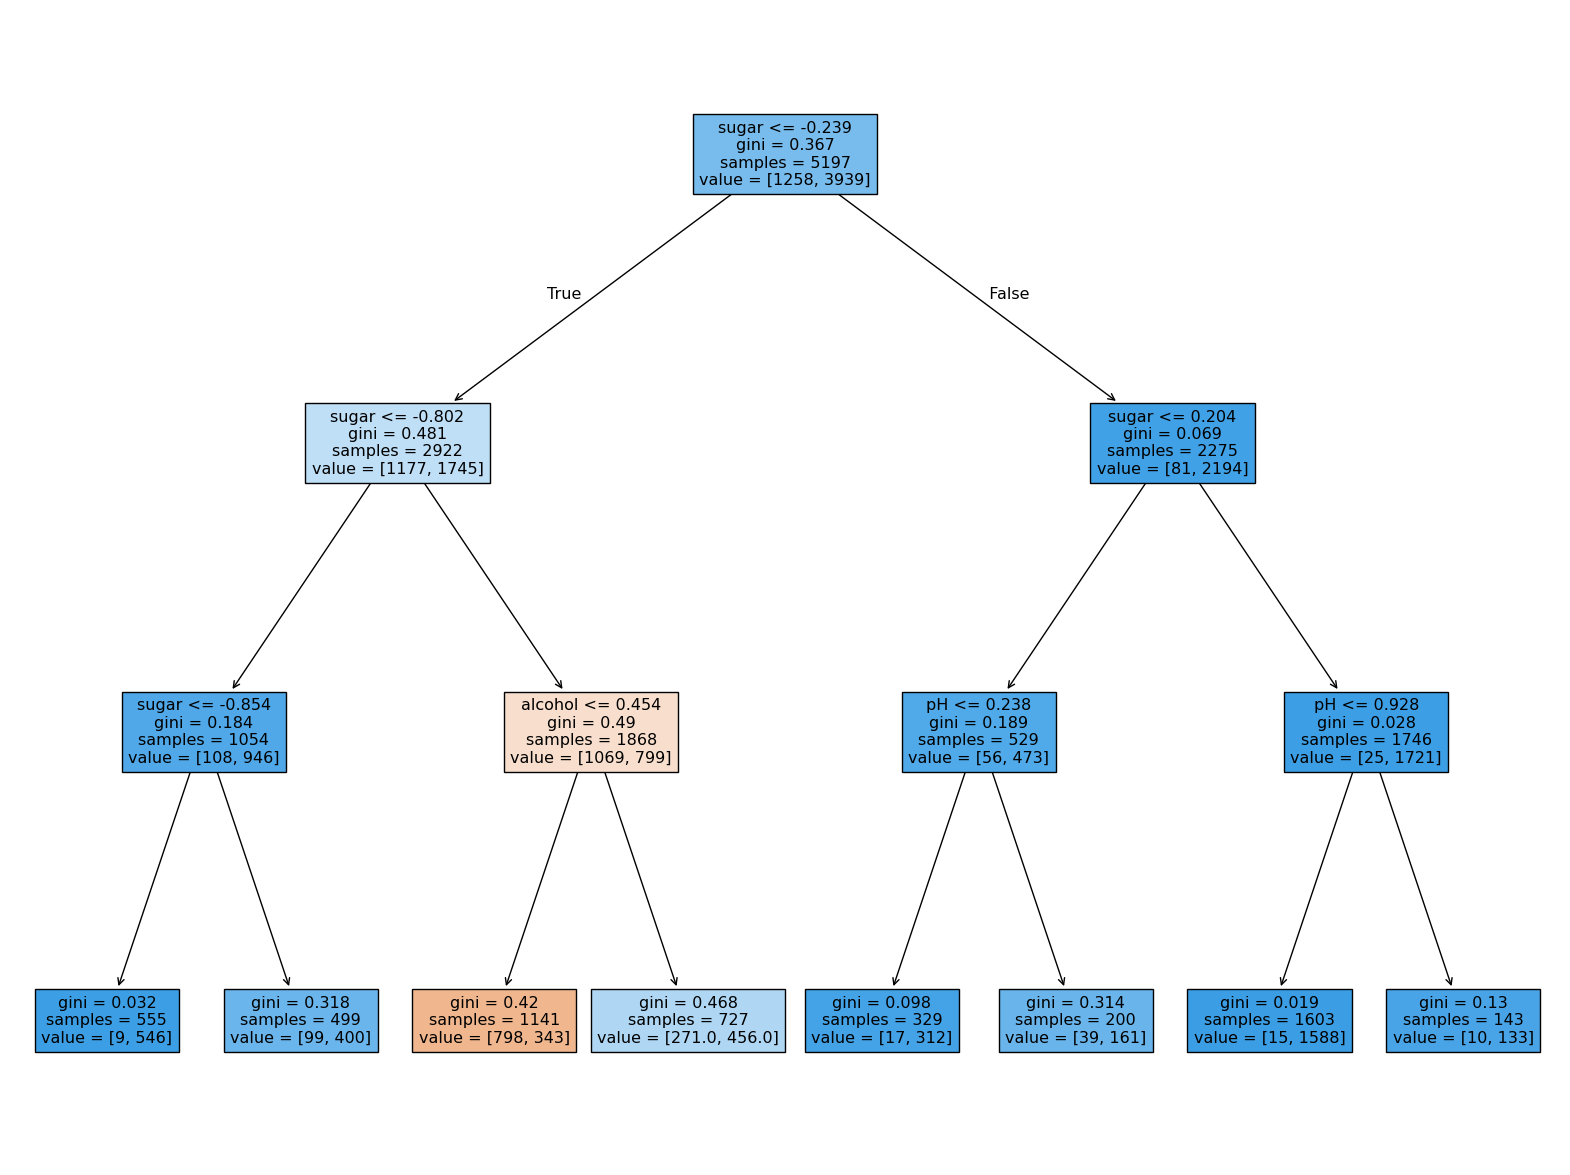

In [12]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))


plt.figure(figsize = (20, 15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

> 결정 트리 알고리즘은 표준화 전처리를 할 필요가 없다

왜냐하면, <br>
불순도를 기준으로 샘플을 나눔<br>
$→$ 불순도는 클래스별 비율을 가지고 계산<br>
$→$ 샘플을 어떤 클래스의 비율로 나누는지 계산할 때, 특성값의 스케일은 상관없음<br>

0.8454877814123533
0.8415384615384616


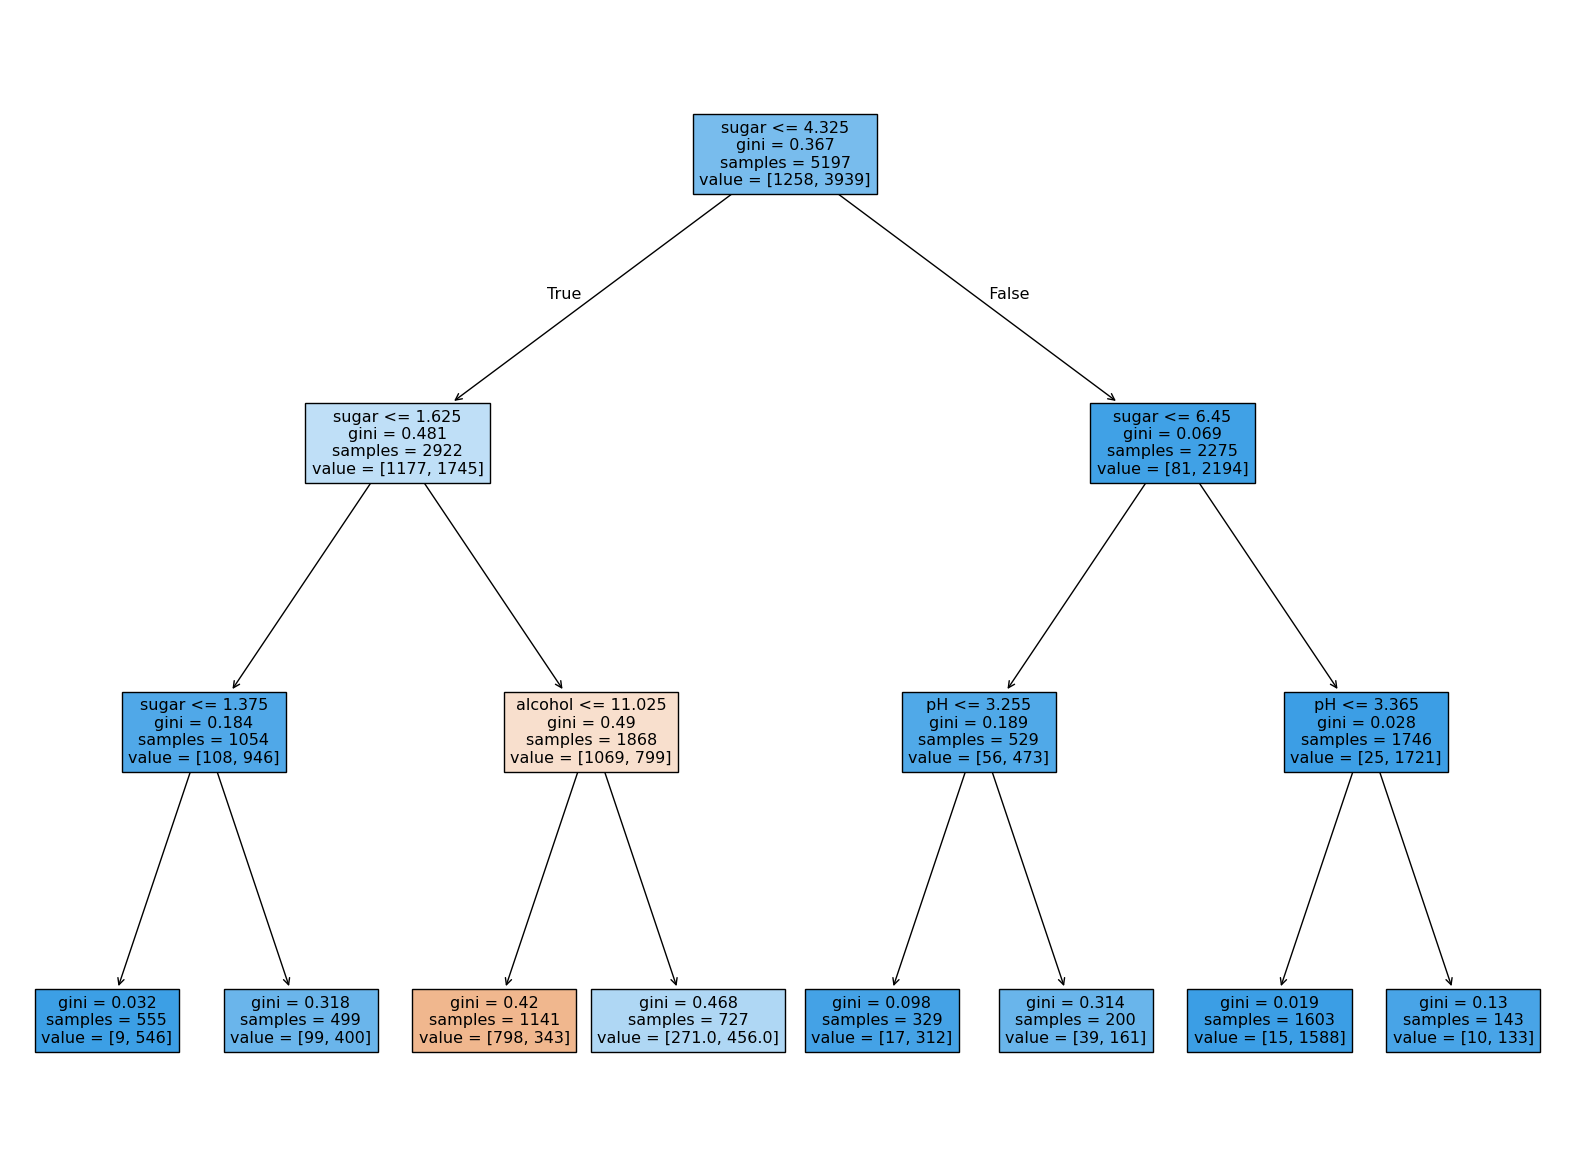

In [15]:
# 전처리하기 전의 훈련/테스트 세트로 다시 훈련
dt = DecisionTreeClassifier(max_depth=3, random_state=4)
dt.fit(train_input, train_target)
print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))

# 전처리된 세트로 출력결과
# 0.8454877814123533
# 0.8415384615384616
# 같음

# 트리 그리기
plt.figure(figsize = (20, 15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()
# 표준점수로 바꾸지 않았기 때문에 이해하기가 훨씬 쉬움

In [16]:
# 결정트리는 특성 중요도를 계산해 줌
# 특성 중요도 : 어떤 특성이 가장 유용한지
# 결정 트리 모델의 feature_importances_ 속성에 저장됨
print(dt.feature_importances_)
# sugar > alcohol, pH

[0.12345626 0.86862934 0.0079144 ]


---
# 요약
- 결정 트리는 예/아니오에 대한 질문을 이어나가면서 정답을 찾아 학습하는 알고리즘
- 불순도 : 결정 트리가 최적의 질문을 찾기 위한 기준(지니, 엔트로피)
- 정보 이득 : 부모 노드와 자식 노드의 불순도 차이, 자식이 순수할수록 높음
- 결정 트리는 제한 없이 성장하는 경우 과대적합 되기 쉬워, max_depth로 가지치기(성장 제한) 필요
- 특성 중요도는 결정 트리에 사용된 특성이 불순도 감소에 기여한 정도, feature_important_에 저장됨)

0.8874350586877044
0.8615384615384616


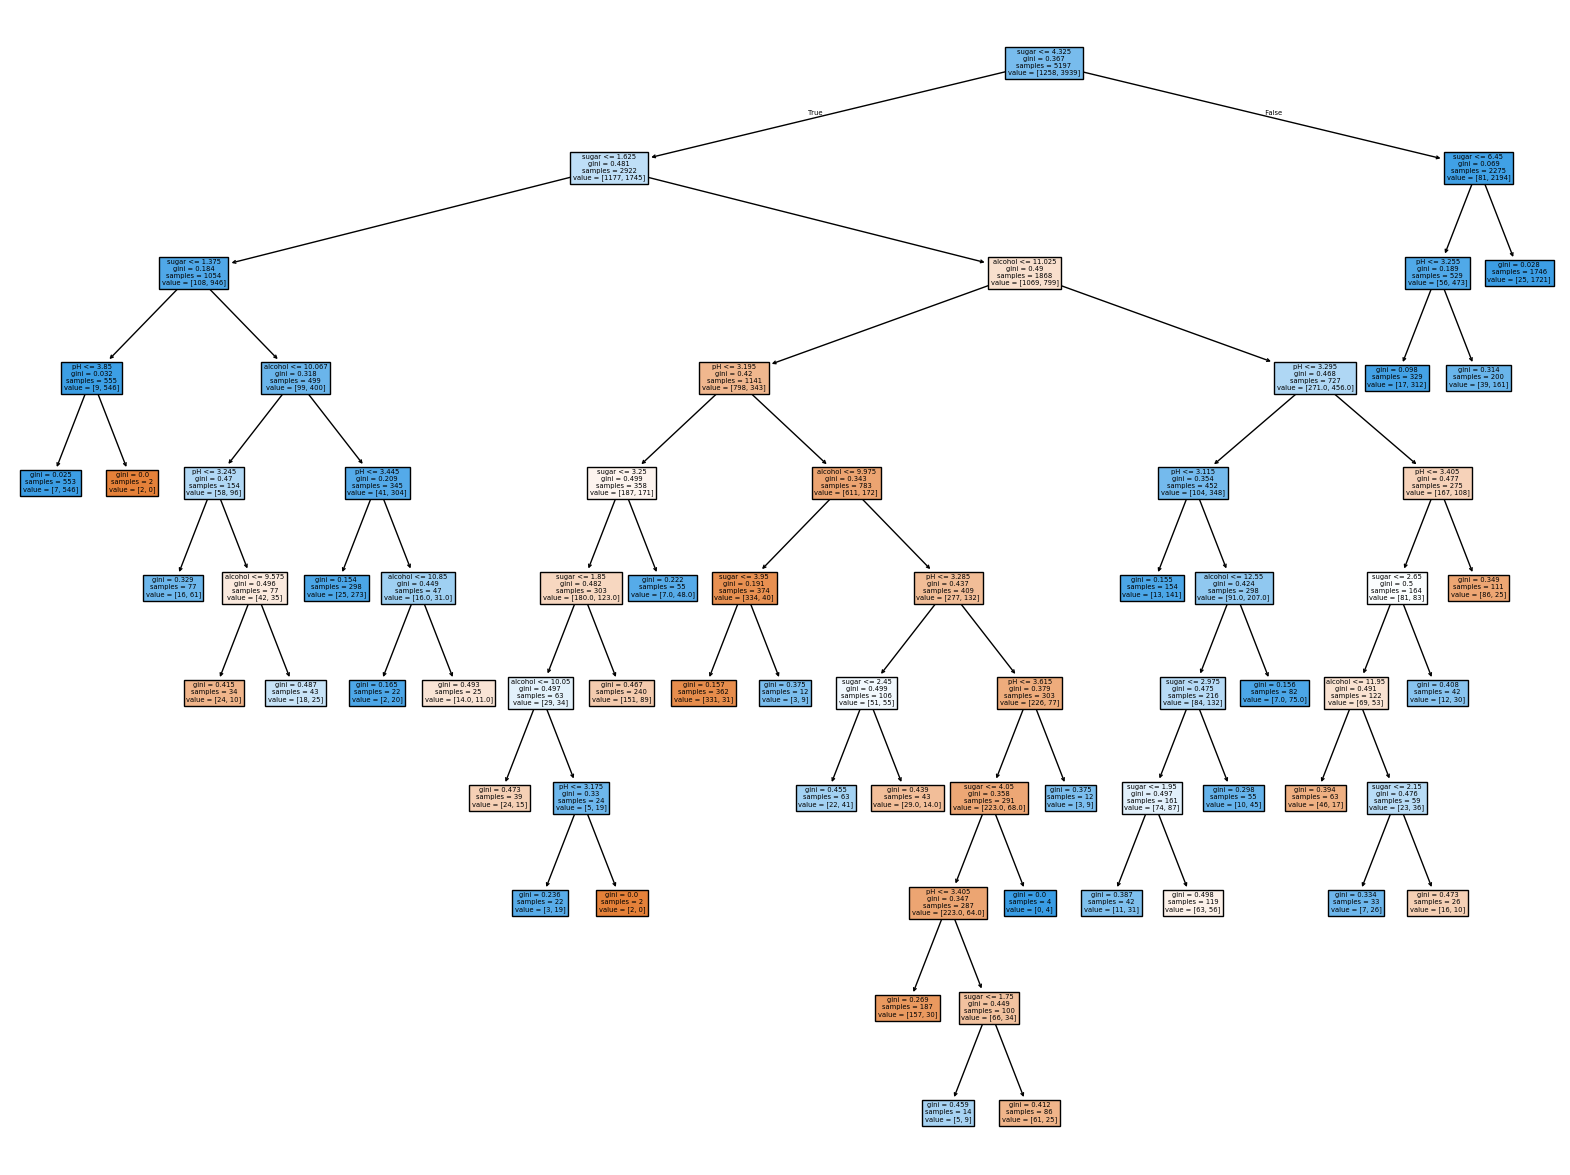

In [17]:
dt = DecisionTreeClassifier(min_impurity_decrease=0.0005, random_state=42)
dt.fit(train_input, train_target)
print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))
plt.figure(figsize = (20, 15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()
